# EDA 07 - Revenue Month Start and End Effect

This notebook analyzes whether revenue differs between the beginning, middle, and end of each month using `sales.csv`. It uses only calendar features derived from the date column and avoids causal claims about payday, campaigns, holidays, or events.

## 1. Setup and file discovery

Locate `sales.csv` recursively from the current working directory and configure common analysis settings. All tables and charts are displayed directly in the notebook.

In [1]:
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path(os.getcwd())
SALES_FILENAME = "sales.csv"
MONTH_POSITION_ORDER = ["month_start", "month_middle", "month_end"]
PAYDAY_PROXY_LABELS = ["non_payday_proxy_window", "payday_proxy_window"]

analysis_ready = False
warning_messages = []
daily = pd.DataFrame()
day_month_stats = pd.DataFrame()
position_stats = pd.DataFrame()
position_pct_diff = pd.DataFrame()
payday_proxy_comparison_df = pd.DataFrame()
year_position_avg = pd.DataFrame()
year_pattern_df = pd.DataFrame()
feature_preview = pd.DataFrame()
day_consistency_df = pd.DataFrame()

highest_revenue_days = []
lowest_revenue_days = []
volatile_days = []
strongest_month_position_group = None
stability_statement = "Not evaluated."
payday_proxy_statement = "Not evaluated."
recommended_features = [
    "day",
    "day_of_month",
    "days_in_month",
    "is_month_start",
    "is_month_end",
    "month_position_group",
    "is_payday_window",
    "day_of_month_sin",
    "day_of_month_cos",
]


def money_formatter(value, _position=None):
    if pd.isna(value):
        return ""
    abs_value = abs(value)
    if abs_value >= 1_000_000_000:
        return f"{value / 1_000_000_000:,.1f}B"
    if abs_value >= 1_000_000:
        return f"{value / 1_000_000:,.1f}M"
    if abs_value >= 1_000:
        return f"{value / 1_000:,.0f}K"
    return f"{value:,.0f}"


currency_axis = FuncFormatter(money_formatter)

sales_matches = sorted(PROJECT_ROOT.rglob(SALES_FILENAME), key=lambda p: (len(p.parts), str(p).lower()))
sales_path = sales_matches[0] if sales_matches else None

file_discovery_df = pd.DataFrame([{
    "file": SALES_FILENAME,
    "found": sales_path is not None,
    "path": str(sales_path.relative_to(PROJECT_ROOT)) if sales_path else None,
    "match_count": len(sales_matches),
}])

if sales_path is None:
    warning_messages.append("sales.csv was not found under the current working directory.")

print(f"Project root: {PROJECT_ROOT}")
display(file_discovery_df)
if len(sales_matches) > 1:
    display(pd.DataFrame({"matched_paths": [str(p.relative_to(PROJECT_ROOT)) for p in sales_matches]}))

Project root: D:\Code\Datathon 2026


,file,found,path,match_count
0,sales.csv,True,datathon-2026-round-1\sales.csv,1


## 2. Load sales data

Load the sales file safely with pandas. If the file cannot be loaded, the notebook shows warnings and skips dependent analysis without crashing.

In [2]:
sales_raw = None
load_error = None

if sales_path is None:
    load_error = "sales.csv was not found."
else:
    try:
        sales_raw = pd.read_csv(sales_path, low_memory=False)
    except Exception as exc:
        load_error = repr(exc)
        warning_messages.append(f"Could not load sales.csv: {load_error}")

if sales_raw is None:
    load_summary_df = pd.DataFrame([{
        "file": SALES_FILENAME,
        "loaded": False,
        "rows": np.nan,
        "columns": np.nan,
        "error": load_error,
    }])
else:
    load_summary_df = pd.DataFrame([{
        "file": SALES_FILENAME,
        "loaded": True,
        "rows": len(sales_raw),
        "columns": len(sales_raw.columns),
        "error": "",
    }])

display(load_summary_df)
if sales_raw is not None:
    display(sales_raw.head())

,file,loaded,rows,columns,error
0,sales.csv,True,3833,3,


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


## 3. Identify date and revenue columns

Detect the most likely date and revenue columns using normalized column names, date parse success, numeric parse success, and revenue-related naming hints. If a direct revenue column is unavailable, numeric columns are scored as possible revenue proxies.

In [3]:
def normalize_name(name):
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")


def non_empty_mask(series):
    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        return series.astype("string").str.strip().ne("") & series.notna()
    return series.notna()


def numeric_series(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    cleaned = (
        series.astype("string")
        .str.strip()
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace(r"^\((.*)\)$", r"-\1", regex=True)
    )
    return pd.to_numeric(cleaned, errors="coerce")


def parse_datetime_series(series):
    if pd.api.types.is_datetime64_any_dtype(series):
        return pd.to_datetime(series, errors="coerce")
    return pd.to_datetime(series, errors="coerce")


def date_score(column_name, series):
    name = normalize_name(column_name)
    name_tokens = set(name.split("_"))
    exact_date_names = {"date", "ds", "day", "sales_date", "order_date", "transaction_date", "created_at", "timestamp"}
    date_terms = {"date", "day", "time", "timestamp", "datetime"}

    name_points = 0
    if name in exact_date_names:
        name_points += 5
    elif name_tokens & date_terms or any(term in name for term in ["date", "timestamp", "datetime"]):
        name_points += 3

    if pd.api.types.is_numeric_dtype(series) and name_points == 0:
        return {
            "column": column_name,
            "normalized_name": name,
            "date_score": -5.0,
            "date_parse_success": 0.0,
            "plausible_date_share": 0.0,
            "non_empty_values": int(non_empty_mask(series).sum()),
        }

    parsed = parse_datetime_series(series)
    mask = non_empty_mask(series)
    non_empty = int(mask.sum())
    parsed_valid = parsed[mask].notna() if non_empty else pd.Series(dtype=bool)
    parse_success = float(parsed_valid.mean()) if non_empty else 0.0

    parsed_non_null = parsed[mask].dropna()
    if len(parsed_non_null):
        plausible = parsed_non_null.between(pd.Timestamp("1990-01-01"), pd.Timestamp("2100-12-31"))
        plausible_share = float(plausible.mean())
        unique_dates = int(parsed_non_null.dt.normalize().nunique())
    else:
        plausible_share = 0.0
        unique_dates = 0

    score = name_points + (3 * parse_success) + (2 * plausible_share) + min(unique_dates / 20, 1)
    return {
        "column": column_name,
        "normalized_name": name,
        "date_score": round(score, 4),
        "date_parse_success": round(parse_success, 4),
        "plausible_date_share": round(plausible_share, 4),
        "non_empty_values": non_empty,
    }


def revenue_score(column_name, series):
    name = normalize_name(column_name)
    name_tokens = set(name.split("_"))
    positive_terms = {
        "revenue": 7,
        "sales": 5,
        "sale": 4,
        "amount": 4,
        "total": 3,
        "value": 2,
        "gmv": 5,
        "turnover": 5,
        "net": 2,
        "gross": 2,
    }
    negative_terms = {
        "id": 6,
        "key": 5,
        "code": 4,
        "date": 6,
        "time": 5,
        "year": 4,
        "month": 4,
        "day": 4,
        "qty": 5,
        "quantity": 5,
        "count": 4,
        "cost": 4,
        "cogs": 5,
        "price": 2,
        "rate": 3,
        "percent": 4,
        "percentage": 4,
    }

    name_points = 0
    for term, points in positive_terms.items():
        if term in name_tokens or term in name:
            name_points += points

    penalty = 0
    for term, points in negative_terms.items():
        if term in name_tokens or term in name:
            penalty += points

    numeric = numeric_series(series)
    mask = non_empty_mask(series)
    non_empty = int(mask.sum())
    numeric_non_null = int(numeric[mask].notna().sum()) if non_empty else 0
    numeric_success = numeric_non_null / non_empty if non_empty else 0.0
    numeric_valid = numeric[mask].dropna()

    if len(numeric_valid):
        positive_share = float((numeric_valid > 0).mean())
        nonzero_share = float((numeric_valid != 0).mean())
        mean_value = float(numeric_valid.mean())
        std_value = float(numeric_valid.std(ddof=1)) if len(numeric_valid) > 1 else 0.0
        abs_median = float(numeric_valid.abs().median())
    else:
        positive_share = 0.0
        nonzero_share = 0.0
        mean_value = np.nan
        std_value = np.nan
        abs_median = 0.0

    variability_points = 1.0 if pd.notna(std_value) and std_value > 0 else 0.0
    magnitude_points = min(np.log10(abs_median + 1) / 4, 1.5) if abs_median > 0 else 0.0
    score = name_points - penalty + (3 * numeric_success) + positive_share + nonzero_share + variability_points + magnitude_points

    return {
        "column": column_name,
        "normalized_name": name,
        "revenue_score": round(float(score), 4),
        "numeric_parse_success": round(float(numeric_success), 4),
        "positive_share": round(float(positive_share), 4),
        "non_empty_values": non_empty,
        "numeric_values": numeric_non_null,
        "mean_numeric_value": mean_value,
        "std_numeric_value": std_value,
        "has_revenue_name_hint": any(term in name for term in ["revenue", "sales", "amount", "gmv", "turnover"]),
    }


if sales_raw is None or sales_raw.empty:
    date_col = None
    revenue_col = None
    parsed_date = None
    parsed_revenue = None
    date_candidates_df = pd.DataFrame()
    revenue_candidates_df = pd.DataFrame()
    column_detection_df = pd.DataFrame([{"warning": "sales.csv was not loaded or is empty."}])
    warning_messages.append("Column detection skipped because sales.csv was not loaded or is empty.")
else:
    date_candidates_df = pd.DataFrame([date_score(col, sales_raw[col]) for col in sales_raw.columns])
    revenue_candidates_df = pd.DataFrame([revenue_score(col, sales_raw[col]) for col in sales_raw.columns])

    date_candidates_df = date_candidates_df.sort_values(["date_score", "date_parse_success", "plausible_date_share"], ascending=False)
    revenue_candidates_df = revenue_candidates_df.sort_values(["revenue_score", "numeric_parse_success", "positive_share"], ascending=False)

    selected_date = date_candidates_df.iloc[0] if len(date_candidates_df) else None
    selected_revenue = revenue_candidates_df.iloc[0] if len(revenue_candidates_df) else None

    date_col = None
    revenue_col = None
    if selected_date is not None and selected_date["date_parse_success"] >= 0.50 and selected_date["plausible_date_share"] >= 0.50:
        date_col = selected_date["column"]

    if selected_revenue is not None and selected_revenue["numeric_parse_success"] >= 0.75 and selected_revenue["revenue_score"] >= 2.0:
        revenue_col = selected_revenue["column"]

    parsed_date = parse_datetime_series(sales_raw[date_col]) if date_col else None
    parsed_revenue = numeric_series(sales_raw[revenue_col]) if revenue_col else None

    if date_col is None:
        warning_messages.append("No usable date column was found. Month-position EDA cannot be completed.")
    if revenue_col is None:
        warning_messages.append("No usable revenue or revenue-like numeric column was found. Month-position EDA cannot be completed.")
    elif not bool(selected_revenue["has_revenue_name_hint"]):
        warning_messages.append(f"Revenue column was inferred from numeric data rather than a direct revenue name: {revenue_col}.")

    column_detection_df = pd.DataFrame([{
        "selected_date_column": date_col,
        "selected_revenue_column": revenue_col,
        "date_parse_success": float(parsed_date.notna().mean()) if parsed_date is not None else np.nan,
        "revenue_numeric_success": float(parsed_revenue.notna().mean()) if parsed_revenue is not None else np.nan,
        "revenue_inferred_without_name_hint": bool(revenue_col and not bool(selected_revenue["has_revenue_name_hint"])),
    }])

print("Selected columns")
display(column_detection_df)
if len(date_candidates_df):
    print("Date candidates")
    display(date_candidates_df)
if len(revenue_candidates_df):
    print("Revenue candidates")
    display(revenue_candidates_df)

Selected columns


,selected_date_column,selected_revenue_column,date_parse_success,revenue_numeric_success,revenue_inferred_without_name_hint
0,Date,Revenue,1.0,1.0,False


Date candidates


,column,normalized_name,date_score,date_parse_success,plausible_date_share,non_empty_values
0,Date,date,11.0,1.0,1.0,3833
1,Revenue,revenue,-5.0,0.0,0.0,3833
2,COGS,cogs,-5.0,0.0,0.0,3833


Revenue candidates


,column,normalized_name,revenue_score,numeric_parse_success,positive_share,non_empty_values,numeric_values,mean_numeric_value,std_numeric_value,has_revenue_name_hint
1,Revenue,revenue,14.5,1.0,1.0,3833,3833,4.286584e+06,2.624840e+06,True
2,COGS,cogs,2.5,1.0,1.0,3833,3833,3.695134e+06,2.219789e+06,False
0,Date,date,-6.0,0.0,0.0,3833,0,NaN,NaN,False


## 4. Prepare daily revenue and day-of-month fields

Parse dates and revenue, aggregate multiple rows per day by summing revenue, and create internal date-derived month-position features. Here `is_month_start` means days 1-7 and `is_month_end` means the last seven calendar days of that month.

In [4]:
if sales_raw is None or date_col is None or revenue_col is None:
    analysis_ready = False
    prep_summary_df = pd.DataFrame([{"ready": False, "warning": "Missing loaded data, date column, or revenue column."}])
    display(prep_summary_df)
else:
    work = pd.DataFrame({
        "date_raw": sales_raw[date_col],
        "revenue_raw": sales_raw[revenue_col],
        "date": parsed_date,
        "revenue": parsed_revenue,
    })
    work["date"] = pd.to_datetime(work["date"], errors="coerce").dt.normalize()

    initial_rows = len(work)
    invalid_date_rows = int(work["date"].isna().sum())
    invalid_revenue_rows = int(work["revenue"].isna().sum())
    work = work.dropna(subset=["date", "revenue"]).copy()

    if work.empty:
        analysis_ready = False
        warning_messages.append("No rows remained after dropping invalid dates or revenue values.")
        prep_summary_df = pd.DataFrame([{
            "ready": False,
            "initial_rows": initial_rows,
            "invalid_date_rows": invalid_date_rows,
            "invalid_revenue_rows": invalid_revenue_rows,
            "usable_rows": 0,
        }])
        display(prep_summary_df)
    else:
        duplicate_date_rows = int(work.duplicated("date", keep=False).sum())
        daily = (
            work.groupby("date", as_index=False)
            .agg(revenue=("revenue", "sum"), source_rows=("revenue", "size"))
            .sort_values("date")
            .reset_index(drop=True)
        )

        full_calendar = pd.date_range(daily["date"].min(), daily["date"].max(), freq="D")
        observed_dates = pd.DatetimeIndex(daily["date"])
        missing_dates = full_calendar.difference(observed_dates)
        inferred_frequency = pd.infer_freq(observed_dates) if len(observed_dates) >= 3 else None
        median_gap_days = float(daily["date"].diff().dt.days.dropna().median()) if len(daily) > 1 else np.nan

        daily["day"] = daily["date"].dt.day
        daily["day_of_month"] = daily["date"].dt.day
        daily["days_in_month"] = daily["date"].dt.days_in_month
        daily["days_until_month_end"] = daily["days_in_month"] - daily["day_of_month"]
        daily["is_month_start"] = daily["day_of_month"].between(1, 7)
        daily["is_month_end"] = daily["days_until_month_end"].between(0, 6)
        daily["month_position_group"] = np.select(
            [daily["is_month_start"], daily["is_month_end"]],
            ["month_start", "month_end"],
            default="month_middle",
        )
        daily["month_position_group"] = pd.Categorical(daily["month_position_group"], categories=MONTH_POSITION_ORDER, ordered=True)
        daily["is_payday_window"] = daily["day_of_month"].between(25, 31) | daily["day_of_month"].between(1, 5)
        daily["day_of_month_sin"] = np.sin(2 * np.pi * (daily["day_of_month"] - 1) / daily["days_in_month"])
        daily["day_of_month_cos"] = np.cos(2 * np.pi * (daily["day_of_month"] - 1) / daily["days_in_month"])
        daily["year"] = daily["date"].dt.year
        daily["year_month"] = daily["date"].dt.to_period("M")
        daily["payday_proxy_group"] = np.where(daily["is_payday_window"], "payday_proxy_window", "non_payday_proxy_window")

        analysis_ready = True
        if duplicate_date_rows:
            warning_messages.append(f"Found {duplicate_date_rows:,} source rows on dates with duplicates; revenue was aggregated by date using sum.")
        if len(missing_dates):
            warning_messages.append(f"Found {len(missing_dates):,} missing calendar dates between the first and last observed sales dates; analysis uses observed dates only.")
        if pd.notna(median_gap_days) and median_gap_days > 1:
            warning_messages.append(f"Observed dates are not contiguous daily records; median gap is {median_gap_days:.1f} days.")

        prep_summary_df = pd.DataFrame([{
            "ready": True,
            "initial_rows": initial_rows,
            "invalid_date_rows": invalid_date_rows,
            "invalid_revenue_rows": invalid_revenue_rows,
            "usable_source_rows": len(work),
            "daily_rows_after_aggregation": len(daily),
            "duplicate_date_source_rows": duplicate_date_rows,
            "first_date": daily["date"].min().date(),
            "last_date": daily["date"].max().date(),
            "expected_calendar_days": len(full_calendar),
            "missing_calendar_days": len(missing_dates),
            "inferred_observed_frequency": inferred_frequency,
            "median_gap_days": median_gap_days,
        }])
        display(prep_summary_df)
        display(daily.head(10))

,ready,initial_rows,invalid_date_rows,invalid_revenue_rows,usable_source_rows,daily_rows_after_aggregation,duplicate_date_source_rows,first_date,last_date,expected_calendar_days,missing_calendar_days,inferred_observed_frequency,median_gap_days
0,True,3833,0,0,3833,3833,0,2012-07-04,2022-12-31,3833,0,D,1.0


,date,revenue,source_rows,day,day_of_month,days_in_month,days_until_month_end,is_month_start,is_month_end,month_position_group,is_payday_window,day_of_month_sin,day_of_month_cos,year,year_month,payday_proxy_group
0,2012-07-04,5123547.94,1,4,4,31,27,True,False,month_start,True,0.571268,0.820763,2012,2012-07,payday_proxy_window
1,2012-07-05,2751773.45,1,5,5,31,26,True,False,month_start,True,0.724793,0.688967,2012,2012-07,payday_proxy_window
2,2012-07-06,3054029.42,1,6,6,31,25,True,False,month_start,False,0.848644,0.528964,2012,2012-07,non_payday_proxy_window
3,2012-07-07,2667930.94,1,7,7,31,24,True,False,month_start,False,0.937752,0.347305,2012,2012-07,non_payday_proxy_window
4,2012-07-08,2360851.90,1,8,8,31,23,False,False,month_middle,False,0.988468,0.151428,2012,2012-07,non_payday_proxy_window
5,2012-07-09,3548386.46,1,9,9,31,22,False,False,month_middle,False,0.998717,-0.050649,2012,2012-07,non_payday_proxy_window
6,2012-07-10,5234938.62,1,10,10,31,21,False,False,month_middle,False,0.968077,-0.250653,2012,2012-07,non_payday_proxy_window
7,2012-07-11,5582884.78,1,11,11,31,20,False,False,month_middle,False,0.897805,-0.440394,2012,2012-07,non_payday_proxy_window
8,2012-07-12,5734632.02,1,12,12,31,19,False,False,month_middle,False,0.790776,-0.612106,2012,2012-07,non_payday_proxy_window
9,2012-07-13,5309511.71,1,13,13,31,18,False,False,month_middle,False,0.651372,-0.758758,2012,2012-07,non_payday_proxy_window


## 5. Revenue by day of month

Calculate revenue statistics for each day of month, identify high and low average-revenue days, and flag volatile days. Days 29, 30, and 31 are shown with observation coverage because not every month contains those dates.

Revenue statistics by day of month


,day_of_month,total_revenue,average_daily_revenue,median_daily_revenue,std_daily_revenue,number_of_observations,possible_months_in_observed_range,observed_months,observation_rate,coefficient_of_variation,rank_by_average_revenue
0,1,7.934587e+08,6.347669e+06,5304546.990,3.924074e+06,125,126,125,0.992063,0.618191,4.0
1,2,6.063351e+08,4.850681e+06,3503909.610,3.940987e+06,125,126,125,0.992063,0.812461,7.0
2,3,5.203609e+08,4.162887e+06,2713373.580,3.426493e+06,125,126,125,0.992063,0.823105,13.0
3,4,3.382215e+08,2.684298e+06,2495820.680,1.567236e+06,126,126,126,1.000000,0.583853,31.0
4,5,3.466618e+08,2.751284e+06,2474430.145,1.297804e+06,126,126,126,1.000000,0.471709,30.0
5,6,3.659111e+08,2.904057e+06,2616421.905,1.293642e+06,126,126,126,1.000000,0.445460,29.0
6,7,3.762245e+08,2.985909e+06,2753025.265,1.349702e+06,126,126,126,1.000000,0.452024,28.0
7,8,3.944320e+08,3.130413e+06,2905164.575,1.425082e+06,126,126,126,1.000000,0.455238,27.0
8,9,4.190711e+08,3.325961e+06,3069914.890,1.488441e+06,126,126,126,1.000000,0.447522,26.0
9,10,4.367656e+08,3.466394e+06,3347110.830,1.558351e+06,126,126,126,1.000000,0.449560,25.0


Highest average-revenue days of month


,day_of_month,total_revenue,average_daily_revenue,median_daily_revenue,std_daily_revenue,number_of_observations,possible_months_in_observed_range,observed_months,observation_rate,coefficient_of_variation,rank_by_average_revenue
30,31,5.610324e+08,7.581519e+06,6629925.795,3.993788e+06,74,74,74,1.000000,0.526779,1.0
29,30,8.423345e+08,7.261505e+06,6298340.330,3.959363e+06,116,116,116,1.000000,0.545254,2.0
28,29,7.849453e+08,6.652078e+06,6156218.355,3.353908e+06,118,118,118,1.000000,0.504189,3.0
0,1,7.934587e+08,6.347669e+06,5304546.990,3.924074e+06,125,126,125,0.992063,0.618191,4.0
27,28,7.483857e+08,5.939569e+06,5363530.365,2.928514e+06,126,126,126,1.000000,0.493052,5.0
26,27,6.346716e+08,5.037076e+06,4629754.015,2.575616e+06,126,126,126,1.000000,0.511331,6.0
1,2,6.063351e+08,4.850681e+06,3503909.610,3.940987e+06,125,126,125,0.992063,0.812461,7.0


Lowest average-revenue days of month


...

,day_of_month,total_revenue,average_daily_revenue,median_daily_revenue,std_daily_revenue,number_of_observations,possible_months_in_observed_range,observed_months,observation_rate,coefficient_of_variation,rank_by_average_revenue
2,3,5.203609e+08,4.162887e+06,2713373.580,3.426493e+06,125,126,125,0.992063,0.823105,13.0
1,2,6.063351e+08,4.850681e+06,3503909.610,3.940987e+06,125,126,125,0.992063,0.812461,7.0
0,1,7.934587e+08,6.347669e+06,5304546.990,3.924074e+06,125,126,125,0.992063,0.618191,4.0
3,4,3.382215e+08,2.684298e+06,2495820.680,1.567236e+06,126,126,126,1.000000,0.583853,31.0
29,30,8.423345e+08,7.261505e+06,6298340.330,3.959363e+06,116,116,116,1.000000,0.545254,2.0
30,31,5.610324e+08,7.581519e+06,6629925.795,3.993788e+06,74,74,74,1.000000,0.526779,1.0
24,25,5.749971e+08,4.563469e+06,4151893.345,2.395421e+06,126,126,126,1.000000,0.524912,9.0
22,23,5.343851e+08,4.241151e+06,3899059.205,2.180483e+06,126,126,126,1.000000,0.514125,10.0


Repeated high-revenue day candidates across years


,day_of_month,years_observed,share_years_above_year_median,share_years_below_year_median,average_revenue_across_year_day_means,average_daily_revenue,number_of_observations,observation_rate
30,31,11,1.0,0.0,7.566389e+06,7.581519e+06,74,1.000000
29,30,11,1.0,0.0,7.219093e+06,7.261505e+06,116,1.000000
28,29,11,1.0,0.0,6.625740e+06,6.652078e+06,118,1.000000
0,1,11,1.0,0.0,6.340503e+06,6.347669e+06,125,0.992063
27,28,11,1.0,0.0,5.953999e+06,5.939569e+06,126,1.000000
26,27,11,1.0,0.0,5.022259e+06,5.037076e+06,126,1.000000
25,26,11,1.0,0.0,4.610060e+06,4.640894e+06,126,1.000000


Repeated low-revenue day candidates across years


,day_of_month,years_observed,share_years_above_year_median,share_years_below_year_median,average_revenue_across_year_day_means,average_daily_revenue,number_of_observations,observation_rate
3,4,11,0.0,1.0,2.733446e+06,2.684298e+06,126,1.0
4,5,11,0.0,1.0,2.745876e+06,2.751284e+06,126,1.0
5,6,11,0.0,1.0,2.907817e+06,2.904057e+06,126,1.0
6,7,11,0.0,1.0,2.968486e+06,2.985909e+06,126,1.0
7,8,11,0.0,1.0,3.116657e+06,3.130413e+06,126,1.0
8,9,11,0.0,1.0,3.342468e+06,3.325961e+06,126,1.0
9,10,11,0.0,1.0,3.478622e+06,3.466394e+06,126,1.0


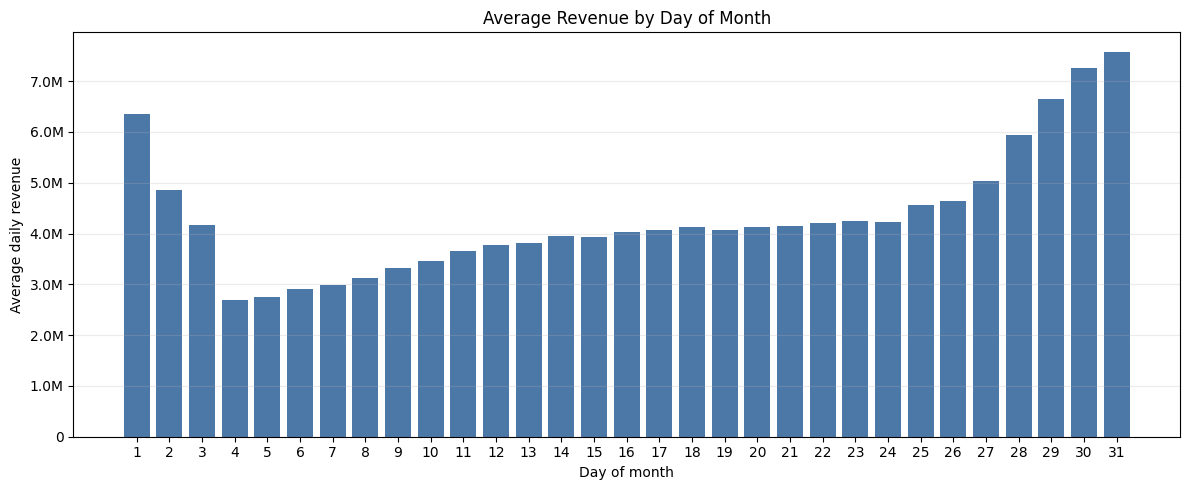

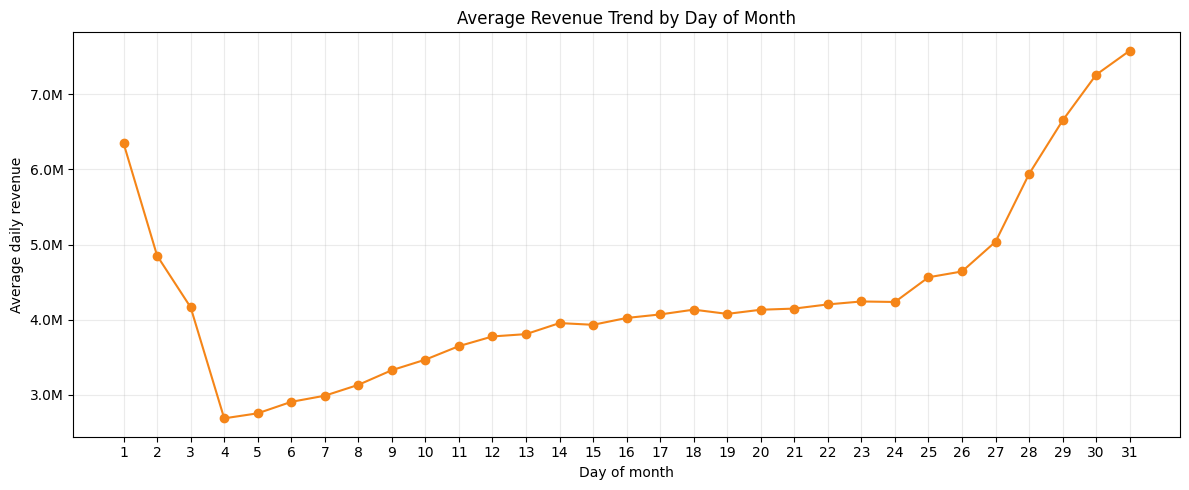

In [5]:
if not analysis_ready:
    print("WARNING: Skipping day-of-month revenue analysis because usable daily revenue data is not available.")
else:
    month_periods = pd.period_range(daily["date"].min(), daily["date"].max(), freq="M")
    possible_months_by_day = {day: int(sum(period.days_in_month >= day for period in month_periods)) for day in range(1, 32)}
    observed_months_by_day = daily.groupby("day_of_month")["year_month"].nunique().reindex(range(1, 32), fill_value=0)

    day_month_stats = (
        daily.groupby("day_of_month")
        .agg(
            total_revenue=("revenue", "sum"),
            average_daily_revenue=("revenue", "mean"),
            median_daily_revenue=("revenue", "median"),
            std_daily_revenue=("revenue", "std"),
            number_of_observations=("revenue", "size"),
        )
        .reindex(range(1, 32))
    )
    day_month_stats.index.name = "day_of_month"
    day_month_stats["possible_months_in_observed_range"] = [possible_months_by_day[day] for day in day_month_stats.index]
    day_month_stats["observed_months"] = observed_months_by_day
    day_month_stats["observation_rate"] = day_month_stats["observed_months"] / day_month_stats["possible_months_in_observed_range"].replace(0, np.nan)
    day_month_stats["coefficient_of_variation"] = day_month_stats["std_daily_revenue"] / day_month_stats["average_daily_revenue"].abs()
    day_month_stats["rank_by_average_revenue"] = day_month_stats["average_daily_revenue"].rank(ascending=False, method="min")
    day_month_stats = day_month_stats.reset_index()

    valid_day_stats = day_month_stats.dropna(subset=["average_daily_revenue"]).copy()
    highest_day_df = valid_day_stats.sort_values("average_daily_revenue", ascending=False).head(7)
    lowest_day_df = valid_day_stats.sort_values("average_daily_revenue", ascending=True).head(7)
    highest_revenue_days = highest_day_df["day_of_month"].astype(int).tolist()
    lowest_revenue_days = lowest_day_df["day_of_month"].astype(int).tolist()

    volatility_pool = valid_day_stats[valid_day_stats["number_of_observations"] >= max(4, valid_day_stats["number_of_observations"].median() * 0.25)]
    if len(volatility_pool):
        volatility_threshold = volatility_pool["coefficient_of_variation"].quantile(0.75)
        volatile_day_df = volatility_pool.loc[
            volatility_pool["coefficient_of_variation"] >= volatility_threshold
        ].sort_values("coefficient_of_variation", ascending=False)
        volatile_days = volatile_day_df["day_of_month"].astype(int).tolist()
    else:
        volatile_day_df = pd.DataFrame()
        volatile_days = []

    print("Revenue statistics by day of month")
    display(day_month_stats)
    print("Highest average-revenue days of month")
    display(highest_day_df)
    print("Lowest average-revenue days of month")
    display(lowest_day_df)
    print("High-volatility days by top-quartile coefficient of variation")
    display(volatile_day_df)

    year_day_avg = daily.groupby(["year", "day_of_month"])["revenue"].mean().unstack("day_of_month").reindex(columns=range(1, 32))
    year_median_by_day = year_day_avg.median(axis=1, skipna=True)
    consistency_rows = []
    for day in range(1, 32):
        values = year_day_avg[day].dropna()
        if values.empty:
            continue
        comparable_medians = year_median_by_day.loc[values.index]
        above_share = float((values > comparable_medians).mean())
        below_share = float((values < comparable_medians).mean())
        consistency_rows.append({
            "day_of_month": day,
            "years_observed": int(values.notna().sum()),
            "share_years_above_year_median": above_share,
            "share_years_below_year_median": below_share,
            "average_revenue_across_year_day_means": float(values.mean()),
        })

    day_consistency_df = pd.DataFrame(consistency_rows)
    if not day_consistency_df.empty:
        day_consistency_df = day_consistency_df.merge(
            valid_day_stats[["day_of_month", "average_daily_revenue", "number_of_observations", "observation_rate"]],
            on="day_of_month",
            how="left",
        )
        repeated_high_days_df = day_consistency_df.sort_values(
            ["share_years_above_year_median", "average_daily_revenue"], ascending=[False, False]
        ).head(7)
        repeated_low_days_df = day_consistency_df.sort_values(
            ["share_years_below_year_median", "average_daily_revenue"], ascending=[False, True]
        ).head(7)
        print("Repeated high-revenue day candidates across years")
        display(repeated_high_days_df)
        print("Repeated low-revenue day candidates across years")
        display(repeated_low_days_df)

    plot_df = valid_day_stats.sort_values("day_of_month")
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(plot_df["day_of_month"].astype(int), plot_df["average_daily_revenue"], color="#4C78A8")
    ax.set_title("Average Revenue by Day of Month")
    ax.set_xlabel("Day of month")
    ax.set_ylabel("Average daily revenue")
    ax.set_xticks(range(1, 32))
    ax.yaxis.set_major_formatter(currency_axis)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(plot_df["day_of_month"].astype(int), plot_df["average_daily_revenue"], marker="o", color="#F58518")
    ax.set_title("Average Revenue Trend by Day of Month")
    ax.set_xlabel("Day of month")
    ax.set_ylabel("Average daily revenue")
    ax.set_xticks(range(1, 32))
    ax.yaxis.set_major_formatter(currency_axis)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 6. Month start vs middle vs month end comparison

Compare observed revenue across the beginning, middle, and end of the month. These are internal date-derived groups: days 1-7, the last seven days, and all remaining observed days.

Month-position revenue statistics


,group,total_revenue,average_daily_revenue,median_daily_revenue,std_daily_revenue,number_of_days,coefficient_of_variation,average_revenue_pct_vs_overall
0,month_start,3.347174e+09,3.807934e+06,2839296.130,2.959755e+06,879,0.777260,-11.166246
1,month_middle,8.040213e+09,3.880412e+06,3511440.335,1.886308e+06,2072,0.486110,-9.475435
2,month_end,5.043090e+09,5.717789e+06,5037568.965,3.194675e+06,882,0.558726,33.388017


Pairwise percentage difference in average daily revenue


row_group_minus_column_group_pct,month_start,month_middle,month_end
row_group_minus_column_group_pct,,,
month_start,0.000000,-1.867792,-33.401998
month_middle,1.903343,0.000000,-32.134410
month_end,50.154655,47.350078,0.000000


Strongest month-position group by average revenue: month_end


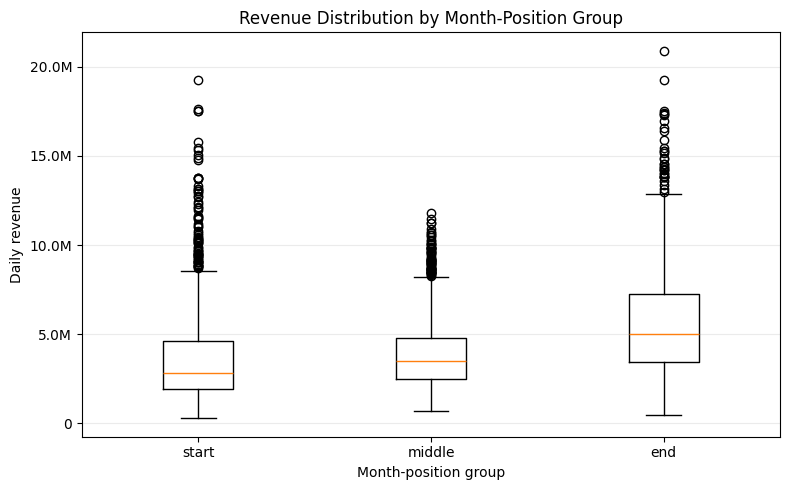

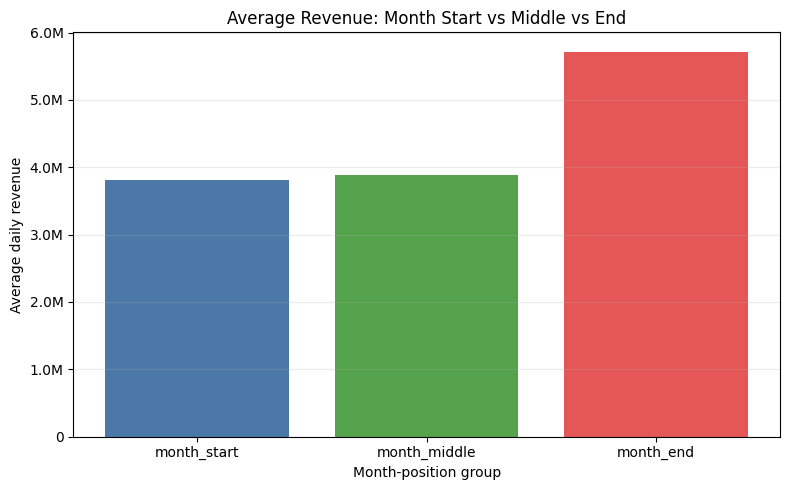

In [6]:
if not analysis_ready:
    print("WARNING: Skipping month-position comparison because usable daily revenue data is not available.")
else:
    position_stats = (
        daily.groupby("month_position_group", observed=True)
        .agg(
            total_revenue=("revenue", "sum"),
            average_daily_revenue=("revenue", "mean"),
            median_daily_revenue=("revenue", "median"),
            std_daily_revenue=("revenue", "std"),
            number_of_days=("revenue", "size"),
        )
        .reindex(MONTH_POSITION_ORDER)
    )
    position_stats["coefficient_of_variation"] = position_stats["std_daily_revenue"] / position_stats["average_daily_revenue"].abs()
    overall_average = daily["revenue"].mean()
    position_stats["average_revenue_pct_vs_overall"] = (position_stats["average_daily_revenue"] - overall_average) / overall_average * 100 if overall_average != 0 else np.nan
    position_stats = position_stats.reset_index().rename(columns={"month_position_group": "group"})

    valid_position_stats = position_stats.dropna(subset=["average_daily_revenue"]).copy()
    strongest_month_position_group = valid_position_stats.sort_values("average_daily_revenue", ascending=False).iloc[0]["group"] if len(valid_position_stats) else None

    avg_by_group = valid_position_stats.set_index("group")["average_daily_revenue"]
    position_pct_diff = pd.DataFrame(index=avg_by_group.index, columns=avg_by_group.index, dtype=float)
    for row_group in avg_by_group.index:
        for col_group in avg_by_group.index:
            base = avg_by_group.loc[col_group]
            position_pct_diff.loc[row_group, col_group] = (avg_by_group.loc[row_group] - base) / base * 100 if base != 0 else np.nan
    position_pct_diff.index.name = "row_group_minus_column_group_pct"

    print("Month-position revenue statistics")
    display(position_stats)
    print("Pairwise percentage difference in average daily revenue")
    display(position_pct_diff)
    print(f"Strongest month-position group by average revenue: {strongest_month_position_group}")

    boxplot_values = []
    boxplot_labels = []
    for group in MONTH_POSITION_ORDER:
        values = daily.loc[daily["month_position_group"].astype(str) == group, "revenue"].dropna().values
        if len(values):
            boxplot_values.append(values)
            boxplot_labels.append(group.replace("month_", ""))

    if boxplot_values:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.boxplot(boxplot_values, tick_labels=boxplot_labels, showfliers=True)
        ax.set_title("Revenue Distribution by Month-Position Group")
        ax.set_xlabel("Month-position group")
        ax.set_ylabel("Daily revenue")
        ax.yaxis.set_major_formatter(currency_axis)
        ax.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(valid_position_stats["group"], valid_position_stats["average_daily_revenue"], color=["#4C78A8", "#54A24B", "#E45756"][:len(valid_position_stats)])
    ax.set_title("Average Revenue: Month Start vs Middle vs End")
    ax.set_xlabel("Month-position group")
    ax.set_ylabel("Average daily revenue")
    ax.yaxis.set_major_formatter(currency_axis)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

## 7. Proxy payday-window analysis

Define an internal proxy window using only day-of-month logic: days 25-31 and 1-5. This is not actual salary, payroll, campaign, holiday, or event data; it is only a candidate feature for later testing.

,proxy_group,average_revenue,median_revenue,total_revenue,std_revenue,number_of_days
0,non_payday_proxy_window,3.798797e+06,3433822.14,9.094319e+09,1.863171e+06,2394
1,payday_proxy_window,5.098094e+06,4319120.35,7.336157e+09,3.395296e+06,1439


,average_revenue_inside_proxy_window,average_revenue_outside_proxy_window,absolute_difference_inside_minus_outside,percentage_difference_inside_vs_outside,proxy_feature_signal
0,5.098094e+06,3.798797e+06,1.299297e+06,34.20286,The payday-window proxy appears potentially useful because average revenue is higher inside the proxy window.


The payday-window proxy appears potentially useful because average revenue is higher inside the proxy window.
This is a date-derived proxy only; it does not show actual payday behavior without external payroll or payment data.


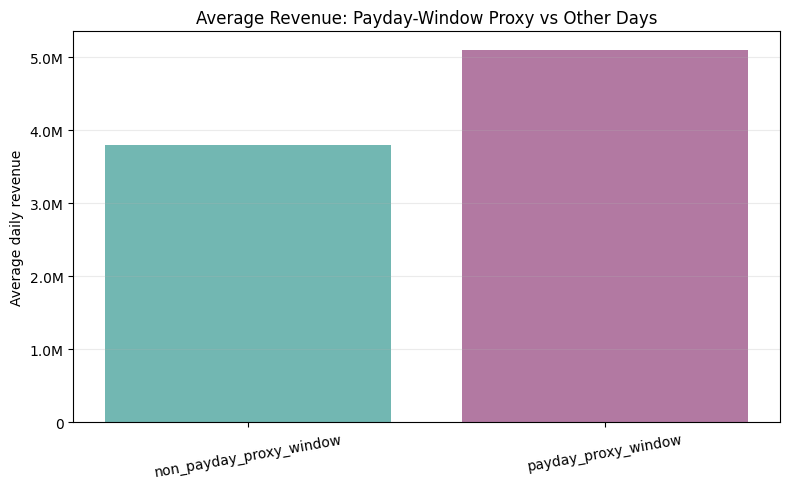

In [7]:
if not analysis_ready:
    print("WARNING: Skipping proxy payday-window analysis because usable daily revenue data is not available.")
else:
    payday_proxy_stats = (
        daily.groupby("payday_proxy_group", observed=True)
        .agg(
            average_revenue=("revenue", "mean"),
            median_revenue=("revenue", "median"),
            total_revenue=("revenue", "sum"),
            std_revenue=("revenue", "std"),
            number_of_days=("revenue", "size"),
        )
        .reindex(PAYDAY_PROXY_LABELS)
    )

    inside_avg = payday_proxy_stats.loc["payday_proxy_window", "average_revenue"] if "payday_proxy_window" in payday_proxy_stats.index else np.nan
    outside_avg = payday_proxy_stats.loc["non_payday_proxy_window", "average_revenue"] if "non_payday_proxy_window" in payday_proxy_stats.index else np.nan
    absolute_difference = inside_avg - outside_avg if pd.notna(inside_avg) and pd.notna(outside_avg) else np.nan
    percentage_difference = (absolute_difference / outside_avg * 100) if pd.notna(absolute_difference) and outside_avg != 0 else np.nan

    if pd.isna(percentage_difference):
        payday_proxy_statement = "The payday-window proxy could not be evaluated."
    elif abs(percentage_difference) <= 5:
        payday_proxy_statement = "The payday-window proxy appears weak or similar to non-window days by average revenue."
    elif percentage_difference > 0:
        payday_proxy_statement = "The payday-window proxy appears potentially useful because average revenue is higher inside the proxy window."
    else:
        payday_proxy_statement = "The payday-window proxy appears potentially useful because average revenue is lower inside the proxy window."

    payday_proxy_comparison_df = pd.DataFrame([{
        "average_revenue_inside_proxy_window": inside_avg,
        "average_revenue_outside_proxy_window": outside_avg,
        "absolute_difference_inside_minus_outside": absolute_difference,
        "percentage_difference_inside_vs_outside": percentage_difference,
        "proxy_feature_signal": payday_proxy_statement,
    }])

    display(payday_proxy_stats.reset_index().rename(columns={"payday_proxy_group": "proxy_group"}))
    display(payday_proxy_comparison_df)
    print(payday_proxy_statement)
    print("This is a date-derived proxy only; it does not show actual payday behavior without external payroll or payment data.")

    plot_df = payday_proxy_stats.dropna(subset=["average_revenue"]).reset_index()
    if len(plot_df):
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar(plot_df["payday_proxy_group"], plot_df["average_revenue"], color=["#72B7B2", "#B279A2"][:len(plot_df)])
        ax.set_title("Average Revenue: Payday-Window Proxy vs Other Days")
        ax.set_xlabel("")
        ax.set_ylabel("Average daily revenue")
        ax.tick_params(axis="x", rotation=10)
        ax.yaxis.set_major_formatter(currency_axis)
        ax.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()

## 8. Stability across years

Compare average revenue by month-position group within each year. This checks whether the strongest group repeats across years or changes over time.

Year x month-position average revenue


month_position_group,month_start,month_middle,month_end
year,,,
2012,3.695035e+06,3.724652e+06,5.355385e+06
2013,4.301902e+06,4.093391e+06,5.826330e+06
2014,4.681696e+06,4.544080e+06,6.945233e+06
2015,4.521135e+06,4.673002e+06,7.018774e+06
2016,4.997117e+06,5.184777e+06,7.836869e+06
2017,4.706908e+06,4.677247e+06,7.075791e+06
2018,4.637927e+06,4.608578e+06,6.579127e+06
2019,2.653795e+06,2.863968e+06,4.162870e+06
2020,2.387477e+06,2.659129e+06,3.898294e+06


Yearly strongest and weakest month-position groups


,year,strongest_group,weakest_group,strongest_average_revenue,weakest_average_revenue,group_spread_pct,profile_correlation_with_overall,noticeable_pattern_change,change_reason
0,2012,month_end,month_start,5.355385e+06,3.695035e+06,38.990403,0.999840,False,
1,2013,month_end,month_middle,5.826330e+06,4.093391e+06,36.555719,0.989663,False,
2,2014,month_end,month_middle,6.945233e+06,4.544080e+06,44.545514,0.996428,False,
3,2015,month_end,month_start,7.018774e+06,4.521135e+06,46.215738,0.999784,False,
4,2016,month_end,month_start,7.836869e+06,4.997117e+06,47.279906,0.999672,False,
5,2017,month_end,month_middle,7.075791e+06,4.677247e+06,43.716017,0.999020,False,
6,2018,month_end,month_middle,6.579127e+06,4.608578e+06,37.354892,0.998920,False,
7,2019,month_end,month_start,4.162870e+06,2.653795e+06,46.765797,0.995450,False,
8,2020,month_end,month_start,3.898294e+06,2.387477e+06,50.670792,0.990771,False,
9,2021,month_end,month_start,3.773598e+06,2.467549e+06,44.150310,0.996523,False,


Month-position patterns appear fairly stable across years.


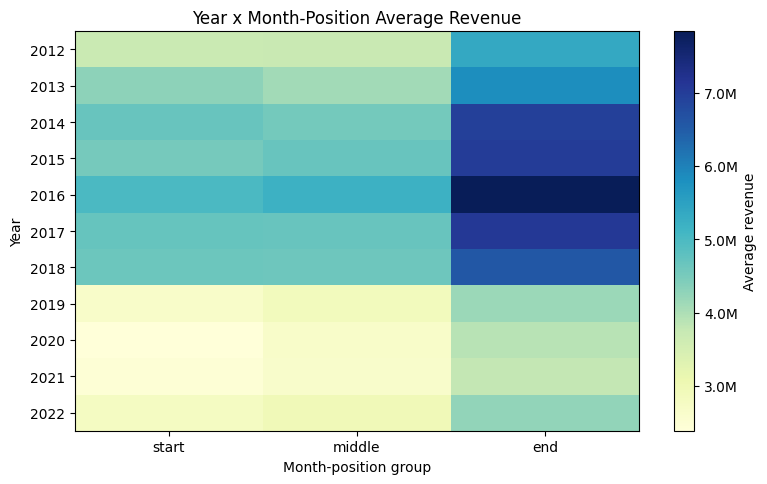

In [8]:
if not analysis_ready:
    print("WARNING: Skipping stability analysis because usable daily revenue data is not available.")
else:
    year_position_avg = (
        daily.groupby(["year", "month_position_group"], observed=True)["revenue"]
        .mean()
        .unstack("month_position_group")
        .reindex(columns=MONTH_POSITION_ORDER)
        .sort_index()
    )

    overall_profile = position_stats.set_index("group")["average_daily_revenue"].reindex(MONTH_POSITION_ORDER)
    overall_strongest = overall_profile.idxmax() if overall_profile.notna().any() else None
    overall_weakest = overall_profile.idxmin() if overall_profile.notna().any() else None
    overall_mean = overall_profile.mean()
    overall_spread_pct = ((overall_profile.max() - overall_profile.min()) / overall_mean * 100) if overall_mean != 0 else np.nan

    pattern_rows = []
    for year, row in year_position_avg.iterrows():
        valid = row.dropna()
        if valid.empty:
            continue
        strongest_for_year = valid.idxmax()
        weakest_for_year = valid.idxmin()
        year_mean = valid.mean()
        spread_pct = ((valid.max() - valid.min()) / year_mean * 100) if year_mean != 0 else np.nan
        corr_valid = row.notna() & overall_profile.notna()
        profile_corr = row[corr_valid].corr(overall_profile[corr_valid]) if int(corr_valid.sum()) >= 3 else np.nan

        reasons = []
        if strongest_for_year != overall_strongest:
            reasons.append("strongest group differs from overall")
        if pd.notna(profile_corr) and profile_corr < 0.25:
            reasons.append("low correlation with overall month-position profile")
        if pd.notna(spread_pct) and pd.notna(overall_spread_pct) and spread_pct > max(10, overall_spread_pct * 1.5):
            reasons.append("larger than usual month-position spread")

        pattern_rows.append({
            "year": year,
            "strongest_group": strongest_for_year,
            "weakest_group": weakest_for_year,
            "strongest_average_revenue": valid.max(),
            "weakest_average_revenue": valid.min(),
            "group_spread_pct": spread_pct,
            "profile_correlation_with_overall": profile_corr,
            "noticeable_pattern_change": bool(reasons),
            "change_reason": "; ".join(reasons),
        })

    year_pattern_df = pd.DataFrame(pattern_rows)
    n_years = len(year_pattern_df)
    if n_years >= 2:
        strongest_share = year_pattern_df["strongest_group"].value_counts(normalize=True).max()
        median_profile_corr = year_pattern_df["profile_correlation_with_overall"].median(skipna=True)
        if strongest_share >= 0.70 and (pd.isna(median_profile_corr) or median_profile_corr >= 0.50):
            stability_statement = "Month-position patterns appear fairly stable across years."
        elif strongest_share >= 0.50 or (pd.notna(median_profile_corr) and median_profile_corr >= 0.25):
            stability_statement = "Month-position patterns appear partly stable, with some year-to-year changes."
        else:
            stability_statement = "Month-position patterns appear to change noticeably across years."
    else:
        stability_statement = "Not enough distinct years to judge month-position pattern stability."

    print("Year x month-position average revenue")
    display(year_position_avg)
    print("Yearly strongest and weakest month-position groups")
    display(year_pattern_df)
    print(stability_statement)

    if not year_position_avg.empty:
        heatmap_data = np.ma.masked_invalid(year_position_avg.to_numpy(dtype=float))
        fig, ax = plt.subplots(figsize=(8, max(4, 0.45 * len(year_position_avg))))
        image = ax.imshow(heatmap_data, aspect="auto", cmap="YlGnBu")
        ax.set_title("Year x Month-Position Average Revenue")
        ax.set_xlabel("Month-position group")
        ax.set_ylabel("Year")
        ax.set_xticks(np.arange(len(MONTH_POSITION_ORDER)))
        ax.set_xticklabels(["start", "middle", "end"])
        ax.set_yticks(np.arange(len(year_position_avg.index)))
        ax.set_yticklabels(year_position_avg.index.astype(str))
        cbar = fig.colorbar(image, ax=ax)
        cbar.set_label("Average revenue")
        cbar.ax.yaxis.set_major_formatter(currency_axis)
        plt.tight_layout()
        plt.show()

## 9. Forecast feature preview

Preview month-position forecast features. The sine and cosine features encode within-month position cyclically, helping models capture repeated month-cycle patterns without treating day 1 and the last day as unrelated extremes.

In [9]:
if not analysis_ready:
    print("WARNING: Skipping forecast feature preview because usable daily revenue data is not available.")
else:
    feature_preview = daily[[
        "date",
        "revenue",
        "day",
        "day_of_month",
        "days_in_month",
        "is_month_start",
        "is_month_end",
        "month_position_group",
        "is_payday_window",
        "day_of_month_sin",
        "day_of_month_cos",
    ]].copy()

    display(feature_preview.head(15))
    print("All previewed features are derived from the date column and same-day revenue; no external calendar, holiday, salary, campaign, or event data is used.")
    print("day_of_month_sin and day_of_month_cos map each date's position within its own month onto a circle, which can help models learn repeating within-month seasonality.")
    print("Recommended baseline month-position features:", ", ".join(recommended_features))

,date,revenue,day,day_of_month,days_in_month,is_month_start,is_month_end,month_position_group,is_payday_window,day_of_month_sin,day_of_month_cos
0,2012-07-04,5123547.94,4,4,31,True,False,month_start,True,0.571268,0.820763
1,2012-07-05,2751773.45,5,5,31,True,False,month_start,True,0.724793,0.688967
2,2012-07-06,3054029.42,6,6,31,True,False,month_start,False,0.848644,0.528964
3,2012-07-07,2667930.94,7,7,31,True,False,month_start,False,0.937752,0.347305
4,2012-07-08,2360851.90,8,8,31,False,False,month_middle,False,0.988468,0.151428
5,2012-07-09,3548386.46,9,9,31,False,False,month_middle,False,0.998717,-0.050649
6,2012-07-10,5234938.62,10,10,31,False,False,month_middle,False,0.968077,-0.250653
7,2012-07-11,5582884.78,11,11,31,False,False,month_middle,False,0.897805,-0.440394
8,2012-07-12,5734632.02,12,12,31,False,False,month_middle,False,0.790776,-0.612106
9,2012-07-13,5309511.71,13,13,31,False,False,month_middle,False,0.651372,-0.758758


All previewed features are derived from the date column and same-day revenue; no external calendar, holiday, salary, campaign, or event data is used.
day_of_month_sin and day_of_month_cos map each date's position within its own month onto a circle, which can help models learn repeating within-month seasonality.
Recommended baseline month-position features: day, day_of_month, days_in_month, is_month_start, is_month_end, month_position_group, is_payday_window, day_of_month_sin, day_of_month_cos


## 10. Key observations and warnings

Summarize the main within-month signals, stability checks, proxy payday-window usefulness, and recommended forecast features. The statements are descriptive and avoid causal claims.

In [10]:
if analysis_ready:
    highest_text = ", ".join(str(day) for day in highest_revenue_days[:5]) if highest_revenue_days else "None"
    lowest_text = ", ".join(str(day) for day in lowest_revenue_days[:5]) if lowest_revenue_days else "None"
    volatile_text = ", ".join(str(day) for day in volatile_days[:7]) if volatile_days else "None flagged"

    if not year_pattern_df.empty and "noticeable_pattern_change" in year_pattern_df:
        changed_years = year_pattern_df.loc[year_pattern_df["noticeable_pattern_change"], "year"].astype(str).tolist()
    else:
        changed_years = []

    if not position_stats.empty and strongest_month_position_group is not None:
        strongest_row = position_stats.loc[position_stats["group"] == strongest_month_position_group].iloc[0]
        strongest_detail = f"{strongest_month_position_group} with average daily revenue {strongest_row['average_daily_revenue']:,.2f}"
    else:
        strongest_detail = "not available"

    if not payday_proxy_comparison_df.empty:
        payday_pct = payday_proxy_comparison_df.loc[0, "percentage_difference_inside_vs_outside"]
        if pd.notna(payday_pct):
            payday_detail = f"{payday_proxy_statement} Difference inside vs outside proxy window: {payday_pct:,.2f}%."
        else:
            payday_detail = payday_proxy_statement
    else:
        payday_detail = payday_proxy_statement

    print("Insight summary")
    print(f"- Highest average-revenue days of month: {highest_text}")
    print(f"- Lowest average-revenue days of month: {lowest_text}")
    print(f"- Strongest month-position group: {strongest_detail}")
    print(f"- Month-position stability across years: {stability_statement}")
    print(f"- Years flagged for noticeable month-position changes: {', '.join(changed_years) if changed_years else 'None flagged'}")
    print(f"- High-volatility days of month: {volatile_text}")
    print(f"- Payday-window proxy usefulness: {payday_detail}")
    print(f"- Recommended forecast features: {', '.join(recommended_features)}")
    print("- Payday, campaign, and shopping-cycle explanations remain hypotheses until tested with supporting external data.")
else:
    print("Insight summary")
    print("- Month-start/end revenue analysis could not be completed because usable date and revenue columns were not available.")

print("\nWarnings and data notes")
if warning_messages:
    for message in dict.fromkeys(warning_messages):
        print(f"- {message}")
else:
    print("- No critical warnings.")

Insight summary
- Highest average-revenue days of month: 31, 30, 29, 1, 28
- Lowest average-revenue days of month: 4, 5, 6, 7, 8
- Strongest month-position group: month_end with average daily revenue 5,717,789.44
- Month-position stability across years: Month-position patterns appear fairly stable across years.
- Years flagged for noticeable month-position changes: None flagged
- High-volatility days of month: 3, 2, 1, 4, 30, 31, 25
- Payday-window proxy usefulness: The payday-window proxy appears potentially useful because average revenue is higher inside the proxy window. Difference inside vs outside proxy window: 34.20%.
- Recommended forecast features: day, day_of_month, days_in_month, is_month_start, is_month_end, month_position_group, is_payday_window, day_of_month_sin, day_of_month_cos
- Payday, campaign, and shopping-cycle explanations remain hypotheses until tested with supporting external data.

Warnings and data notes
- No critical warnings.
